# GNN for Spatial Cascade Propagation

**Goal:** Given a primary disaster event in a county, predict which **directly adjacent counties**
will experience secondary (cascaded) disaster events — and what types.

| Component | Detail |
|---|---|
| **Graph** | ~3,100 county nodes, ~18K adjacency edges (US Census) |
| **Input** | Per-trigger subgraph: source county + **1-hop** neighbors; features only at the trigger |
| **Prediction** | For each **direct neighbor**: cascade within 48h (multi-label type); labels from **all** events, not same episode only |
| **Model** | 2-layer GAT that propagates disaster risk from source to neighbors |
| **Fairness angle** | Under-reported counties get predictions via neighbor signal |
| **Visualization** | Animated disaster propagation across county graph |

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import warnings
import ast
import os
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss,
    precision_recall_curve, roc_curve, auc
)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}  \u2022  Device: {DEVICE}")

%matplotlib inline

PyTorch 2.8.0  •  Device: cpu


In [2]:
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv
from torch_geometric.utils import add_self_loops, subgraph, k_hop_subgraph
import geopandas as gpd
import requests
print(f"PyG {torch_geometric.__version__}")

PyG 2.6.1


---
## 1. Data Loading & County Graph

In [3]:
DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
CACHE_DIR = DATA_DIR / 'gnn_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path('../models/gnn')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path('../results/gnn')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading events ...")
events = pd.read_csv(
    PROCESSED_DIR / 'events_labeled_full.csv',
    usecols=[
        'EVENT_ID', 'EPISODE_ID', 'EVENT_TYPE', 'STATE', 'STATE_FIPS',
        'CZ_FIPS', 'CZ_TYPE', 'CZ_NAME', 'LOCATION_KEY',
        'BEGIN_DATETIME', 'END_DATETIME',
        'BEGIN_LAT', 'BEGIN_LON',
        'MAGNITUDE', 'INJURIES_DIRECT', 'INJURIES_INDIRECT',
        'DEATHS_DIRECT', 'DEATHS_INDIRECT',
        'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD', 'TOTAL_DAMAGE_USD',
        'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH',
        'target', 'is_cascade', 'is_cascade_result',
    ],
    parse_dates=['BEGIN_DATETIME', 'END_DATETIME'],
)
print(f"  Total events: {len(events):,}")

# County-type only (reliable FIPS)
events = events[events['CZ_TYPE'] == 'C'].copy()
events['FIPS'] = (events['STATE_FIPS'].astype(str).str.zfill(2) +
                  events['CZ_FIPS'].astype(str).str.zfill(3))
print(f"  County events: {len(events):,}, {events['FIPS'].nunique()} counties")

# Parse targets
events['target_parsed'] = events['target'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])
events['has_cascade'] = events['target_parsed'].apply(lambda x: len(x) > 0)
events['is_cascade_result'] = events['is_cascade_result'].isin([True, 'True', 1])
events['year'] = events['BEGIN_DATETIME'].dt.year

print(f"  Events triggering cascades: {events['has_cascade'].sum():,}")
print(f"  Events that are cascade results: {events['is_cascade_result'].sum():,}")

Loading events ...


  Total events: 967,441


  County events: 559,620, 3267 counties


  Events triggering cascades: 144,800
  Events that are cascade results: 138,853


In [4]:
# ── County adjacency graph ────────────────────────────────────────────
ADJ_CACHE = CACHE_DIR / 'county_adjacency.csv'
if ADJ_CACHE.exists():
    print("Loading cached county adjacency ...")
    adj_df = pd.read_csv(ADJ_CACHE, dtype=str)
else:
    print("Downloading US Census county adjacency file ...")
    url = "https://www2.census.gov/geo/docs/reference/county_adjacency/county_adjacency2023.txt"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    import io
    raw_df = pd.read_csv(io.StringIO(resp.text), sep='|', dtype=str)
    raw_df.columns = ['county_name', 'county_fips', 'neighbor_name', 'neighbor_fips']
    adj_df = raw_df[['county_fips', 'neighbor_fips']].dropna().copy()
    adj_df.to_csv(ADJ_CACHE, index=False)

adj_df = adj_df[adj_df['county_fips'] != adj_df['neighbor_fips']].copy()

# Build node set: counties in both events and adjacency
event_fips = set(events['FIPS'].unique())
adj_fips = set(adj_df['county_fips']) | set(adj_df['neighbor_fips'])
common_fips = sorted(event_fips & adj_fips)
fips_to_idx = {f: i for i, f in enumerate(common_fips)}
idx_to_fips = {i: f for f, i in fips_to_idx.items()}
N_NODES = len(common_fips)

# Filter events
events = events[events['FIPS'].isin(common_fips)].copy()

# Build edge_index
src, dst = [], []
for _, row in adj_df.iterrows():
    s, d = row['county_fips'], row['neighbor_fips']
    if s in fips_to_idx and d in fips_to_idx:
        src.append(fips_to_idx[s])
        dst.append(fips_to_idx[d])
        # Add reverse for undirected
        src.append(fips_to_idx[d])
        dst.append(fips_to_idx[s])

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_index = torch.unique(edge_index, dim=1)
edge_index, _ = add_self_loops(edge_index, num_nodes=N_NODES)

# Precompute neighbor sets for fast lookup
neighbor_map = defaultdict(set)
ei_np = edge_index.numpy()
for e in range(ei_np.shape[1]):
    s, d = ei_np[0, e], ei_np[1, e]
    if s != d:
        neighbor_map[s].add(d)

print(f"Graph: {N_NODES} nodes, {edge_index.shape[1]} edges")
print(f"Avg degree: {edge_index.shape[1] / N_NODES:.1f}")

# County centroids for visualization
county_coords = events.groupby('FIPS').agg(
    lat=('BEGIN_LAT', 'median'),
    lon=('BEGIN_LON', 'median'),
    state=('STATE', 'first'),
    name=('CZ_NAME', 'first'),
).reindex(common_fips).fillna(0)
print(f"County centroids: {len(county_coords)}")

Loading cached county adjacency ...


Graph: 3104 nodes, 21496 edges
Avg degree: 6.9
County centroids: 3104


---
## 2. Trigger-Level Training Data (1-hop)

Each training sample is one **trigger event** row (`has_cascade`). The task:
- **Input**: Features of that trigger, seeded at its source county; subgraph = source + **direct neighbors only**
- **Output**: For each node in that subgraph, a multi-hot of cascade types that occur in that county within **48 hours** after the trigger ends — matched against the **full** event table (not restricted to the same `EPISODE_ID`)

The GAT propagates the trigger signal to adjacent counties; loss is applied on **neighbor** nodes (not the source).

In [5]:
# ── Event type encoding ───────────────────────────────────────────────
EVENT_TYPES = sorted(events['EVENT_TYPE'].unique())
N_EVENT_TYPES = len(EVENT_TYPES)
etype_to_idx = {e: i for i, e in enumerate(EVENT_TYPES)}

# ── Target labels ─────────────────────────────────────────────────────
target_counts = defaultdict(int)
for t_list in events['target_parsed']:
    for t in t_list:
        target_counts[t] += 1

MIN_COUNT = 200
TARGET_NAMES = sorted([t for t, c in target_counts.items() if c >= MIN_COUNT])
N_LABELS = len(TARGET_NAMES)
target_to_idx = {t: i for i, t in enumerate(TARGET_NAMES)}

print(f"Event types: {N_EVENT_TYPES}")
print(f"Target labels: {N_LABELS}")
for t in TARGET_NAMES:
    print(f"  {t}: {target_counts[t]:,}")

# ── Per-event feature vector ──────────────────────────────────────────
# [event_type_onehot (N_EVENT_TYPES), log_damage, magnitude,
#  injuries, deaths, duration_hours]
N_EVENT_FEATURES = N_EVENT_TYPES + 5
print(f"\nPer-event feature dim: {N_EVENT_FEATURES}")


def _safe_float(val, default=0.0):
    """Convert value to float, handling NaN/None."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return default
    try:
        return float(val)
    except (ValueError, TypeError):
        return default


def event_to_features(row):
    """Convert one event row to a feature vector."""
    feat = np.zeros(N_EVENT_FEATURES, dtype=np.float32)
    # One-hot event type
    if row['EVENT_TYPE'] in etype_to_idx:
        feat[etype_to_idx[row['EVENT_TYPE']]] = 1.0
    # Continuous features
    feat[N_EVENT_TYPES + 0] = np.log1p(max(_safe_float(row.get('TOTAL_DAMAGE_USD')), 0))
    feat[N_EVENT_TYPES + 1] = max(_safe_float(row.get('MAGNITUDE')), 0)
    feat[N_EVENT_TYPES + 2] = (max(_safe_float(row.get('INJURIES_DIRECT')), 0) +
                                max(_safe_float(row.get('INJURIES_INDIRECT')), 0))
    feat[N_EVENT_TYPES + 3] = (max(_safe_float(row.get('DEATHS_DIRECT')), 0) +
                                max(_safe_float(row.get('DEATHS_INDIRECT')), 0))
    if pd.notna(row.get('BEGIN_DATETIME')) and pd.notna(row.get('END_DATETIME')):
        feat[N_EVENT_FEATURES - 1] = max(
            (row['END_DATETIME'] - row['BEGIN_DATETIME']).total_seconds() / 3600, 0)
    return feat

Event types: 20


Target labels: 7
  Debris Flow: 1,294
  Flash Flood: 43,261
  Flood: 9,842
  Hail: 46,689
  Lightning: 6,379
  Thunderstorm Wind: 47,699
  Tornado: 11,464

Per-event feature dim: 25


In [6]:
# ── Build trigger-level PyG Data objects (1-hop, global 48h labels) ───
# One sample per trigger event row (has_cascade):
#   1. Subgraph = source county + direct neighbors only (1-hop)
#   2. Node features: trigger row only at the source (zeros elsewhere)
#   3. Labels: cascade types with is_cascade_result in (t_anchor, t_anchor+48h],
#      using the full events table — not restricted to the same EPISODE_ID.
#
# t_anchor = trigger END_DATETIME (fallback BEGIN if end missing).

CASCADE_LABEL_HOURS = 7*24
LABEL_WINDOW = pd.Timedelta(hours=CASCADE_LABEL_HOURS)

print("Building 1-hop trigger graphs ...")
t0 = time.time()

# Pre-index cascade-result rows by county — avoids scanning full `events` per neighbor
_ce = events.loc[
    events["is_cascade_result"],
    ["FIPS", "EVENT_TYPE", "BEGIN_DATETIME", "EVENT_ID"],
].copy()
cascade_by_fips = {f: g for f, g in _ce.groupby("FIPS", sort=False)}
print(
    f"  Pre-indexed cascade-result events: {len(_ce):,} rows, "
    f"{len(cascade_by_fips):,} counties"
)

primary_rows = events[events["has_cascade"]].sort_values("BEGIN_DATETIME")
print(f"  Trigger events (rows): {len(primary_rows):,}")

episode_data = []  # list of PyG Data (name kept for downstream cells)
skipped = 0

for _, row in primary_rows.iterrows():
    src_fips = row["FIPS"]
    if src_fips not in fips_to_idx:
        skipped += 1
        continue

    t_anchor = row["END_DATETIME"] if pd.notna(row["END_DATETIME"]) else row["BEGIN_DATETIME"]
    if pd.isna(t_anchor):
        skipped += 1
        continue
    t_end = t_anchor + LABEL_WINDOW
    trigger_eid = row["EVENT_ID"]
    te_str = str(trigger_eid)

    center_nodes = torch.tensor([fips_to_idx[src_fips]], dtype=torch.long)
    sub_nodes, sub_edge_index, _, _ = k_hop_subgraph(
        center_nodes, num_hops=1, edge_index=edge_index,
        relabel_nodes=True, num_nodes=N_NODES
    )
    n_sub = len(sub_nodes)

    if n_sub < 2:
        skipped += 1
        continue

    # Features: single trigger at its county
    x = np.zeros((n_sub, N_EVENT_FEATURES), dtype=np.float32)
    feat_vec = event_to_features(row)
    local_src = None
    for li in range(n_sub):
        if idx_to_fips[int(sub_nodes[li])] == src_fips:
            local_src = li
            x[li] = feat_vec
            break
    else:
        skipped += 1
        continue

    # Labels: only rows for this county from pre-index (fast)
    y = np.zeros((n_sub, N_LABELS), dtype=np.float32)
    for li in range(n_sub):
        gfips = idx_to_fips[int(sub_nodes[li])]
        cdf = cascade_by_fips.get(gfips)
        if cdf is None or len(cdf) == 0:
            continue
        m = (
            (cdf["BEGIN_DATETIME"] > t_anchor)
            & (cdf["BEGIN_DATETIME"] <= t_end)
            & (cdf["EVENT_ID"].astype(str) != te_str)
        )
        for et in cdf.loc[m, "EVENT_TYPE"]:
            if et in target_to_idx:
                y[li, target_to_idx[et]] = 1.0

    is_source = np.zeros(n_sub, dtype=np.float32)
    is_source[local_src] = 1.0

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=sub_edge_index,
        y=torch.tensor(y, dtype=torch.float32),
        is_source=torch.tensor(is_source, dtype=torch.float32),
        global_node_ids=sub_nodes,
        episode_id=row["EPISODE_ID"],
        year=int(row["year"]),
        trigger_event_id=te_str,
        t_anchor=str(t_anchor),
    )
    episode_data.append(data)

elapsed = time.time() - t0
print(f"\nBuilt {len(episode_data):,} trigger graphs in {elapsed:.0f}s (skipped {skipped})")

n_nodes_list = [d.x.shape[0] for d in episode_data]
print(f"Nodes per graph: mean={np.mean(n_nodes_list):.1f}, "
      f"median={np.median(n_nodes_list):.0f}, max={max(n_nodes_list)}")

all_y = torch.cat([d.y for d in episode_data], dim=0).numpy()
n_nbr = sum((d.is_source < 0.5).sum().item() for d in episode_data)
print(f"\nNeighbor node count (1-hop only): {n_nbr:,}")
print(f"Label distribution across all graph nodes (source + neighbors):")
for i, t in enumerate(TARGET_NAMES):
    pos = all_y[:, i].sum()
    print(f"  {t:25s}: {int(pos):,} positive ({pos / len(all_y) * 100:.2f}%)")

nbr_y = torch.cat([d.y[d.is_source < 0.5] for d in episode_data], dim=0).numpy()
print(f"\nPositive rate on neighbor nodes only (any label): "
      f"{(nbr_y.sum(axis=1) > 0).mean() * 100:.2f}%")



Building 1-hop trigger graphs ...
  Pre-indexed cascade-result events: 137,693 rows, 2,998 counties
  Trigger events (rows): 143,539



Built 143,450 trigger graphs in 723s (skipped 89)


Nodes per graph: mean=7.3, median=7, max=15



Neighbor node count (1-hop only): 897,972
Label distribution across all graph nodes (source + neighbors):
  Debris Flow              : 3,368 positive (0.32%)
  Flash Flood              : 122,922 positive (11.80%)
  Flood                    : 41,326 positive (3.97%)
  Hail                     : 197,535 positive (18.97%)
  Lightning                : 14,429 positive (1.39%)
  Thunderstorm Wind        : 204,097 positive (19.60%)
  Tornado                  : 47,215 positive (4.53%)



Positive rate on neighbor nodes only (any label): 28.71%


In [7]:
# ── Chronological split ──────────────────────────────────────────────
train_data = [d for d in episode_data if d.year <= 2022]
val_data   = [d for d in episode_data if d.year == 2023]
test_data  = [d for d in episode_data if d.year >= 2024]

print(f"Train: {len(train_data):,} episodes (<=2022)")
print(f"Val:   {len(val_data):,} episodes (2023)")
print(f"Test:  {len(test_data):,} episodes (>=2024)")

# ── Normalize features ───────────────────────────────────────────────
# Only fit on SOURCE nodes (non-zero) to avoid zero-dominated statistics.
# Non-source nodes stay at zero — the model should learn that zero = no event.
X_source_all = []
for d in train_data:
    src_mask = d.is_source > 0.5
    if src_mask.sum() > 0:
        X_source_all.append(d.x[src_mask])
X_source_all = torch.cat(X_source_all, dim=0).numpy()

# Compute max absolute value per feature for simple normalization
feat_max = np.maximum(np.abs(X_source_all).max(axis=0), 1e-8)
print(f"Scaler fitted on {X_source_all.shape[0]:,} source nodes")

# Apply normalization: divide by max (preserves zeros)
for d in episode_data:
    d.x_scaled = d.x / torch.tensor(feat_max, dtype=torch.float32)

# ── Class weights (capped at 10 for stability) ──────────────────────
Y_train_all = torch.cat([d.y for d in train_data], dim=0).numpy()
pos_counts = Y_train_all.sum(axis=0)
neg_counts = Y_train_all.shape[0] - pos_counts
pos_weight = np.clip(neg_counts / (pos_counts + 1), 1.0, 10.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

print("\nClass weights (capped at 10):")
for i, t in enumerate(TARGET_NAMES):
    print(f"  {t:25s}: pos={int(pos_counts[i]):6,}  weight={pos_weight[i]:.1f}")

Train: 112,258 episodes (<=2022)
Val:   10,780 episodes (2023)
Test:  20,412 episodes (>=2024)


Scaler fitted on 112,258 source nodes



Class weights (capped at 10):
  Debris Flow              : pos= 2,620  weight=10.0
  Flash Flood              : pos=94,365  weight=7.6
  Flood                    : pos=33,645  weight=10.0
  Hail                     : pos=156,152  weight=4.2
  Lightning                : pos=11,917  weight=10.0
  Thunderstorm Wind        : pos=161,030  weight=4.1
  Tornado                  : pos=34,492  weight=10.0


---
## 3. GNN Model — `CascadePropagationGAT`

The model takes a **1-hop** subgraph where the **source county** is seeded with trigger
features and other nodes start at zero. The GAT's message passing propagates
the disaster signal to direct neighbors (and mixes neighbor representations).

- **Layer 1**: 4-head GAT — signal flows from source to neighbors
- **Layer 2**: Single-head GAT — refines representations on the local neighborhood
- **Classifier**: MLP predicts cascade probability per county per disaster type

In [8]:
class CascadePropagationGAT(nn.Module):
    """GAT that propagates disaster risk from source counties to neighbors.
    
    Input: trigger features seeded at the source county, zeros on neighbors (1-hop graph).
    Output: per-county, per-label cascade probability.
    
    Key design: NO residual connections — forces information to flow
    through GAT message passing. Non-source nodes have zero features,
    so residuals would just pass zeros, letting the model ignore propagation.
    """
    def __init__(self, in_dim, hidden_dim=64, n_labels=8,
                 n_heads=4, dropout=0.3):
        super().__init__()
        # Input projection (+ 1 for is_source flag)
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        # GAT Layer 1: multi-head
        self.gat1 = GATConv(
            hidden_dim, hidden_dim // n_heads,
            heads=n_heads, dropout=dropout, concat=True,
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        # GAT Layer 2: single-head
        self.gat2 = GATConv(
            hidden_dim, hidden_dim,
            heads=1, dropout=dropout, concat=False,
        )
        self.norm2 = nn.LayerNorm(hidden_dim)
        # MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_labels),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, is_source, return_attention=False):
        # Concat source flag to features
        h = torch.cat([x, is_source.unsqueeze(-1)], dim=-1)
        h = self.input_proj(h)
        
        # GAT Layer 1 — NO residual (force propagation to neighbors)
        h1, attn1 = self.gat1(h, edge_index, return_attention_weights=True)
        h = self.norm1(F.elu(h1))
        h = self.dropout(h)
        
        # GAT Layer 2 — NO residual
        h2, attn2 = self.gat2(h, edge_index, return_attention_weights=True)
        h = self.norm2(F.elu(h2))
        h = self.dropout(h)
        
        logits = self.classifier(h)
        
        if return_attention:
            return logits, (attn1, attn2)
        return logits


model = CascadePropagationGAT(
    in_dim=N_EVENT_FEATURES, hidden_dim=64, n_labels=N_LABELS,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"CascadePropagationGAT: {n_params:,} parameters")
print("  No residual connections — forces spatial propagation")


CascadePropagationGAT: 27,719 parameters
  No residual connections — forces spatial propagation


---
## 4. Training

In [9]:
def train_one_epoch(model, data_list, optimizer, batch_size=64,
                    nonsource_weight=3.0):
    """Train on mini-batches of trigger graphs.

    Loss is on **direct-neighbor** nodes only (zero weight on source).
    """
    model.train()
    total_loss = 0.0
    n_weighted = 0.0

    indices = np.random.permutation(len(data_list))

    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        batch = Batch.from_data_list(
            [data_list[i] for i in batch_idx])

        x = batch.x_scaled.to(DEVICE)
        ei = batch.edge_index.to(DEVICE)
        y = batch.y.to(DEVICE)
        is_src = batch.is_source.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x, ei, is_src)

        loss_per_node = F.binary_cross_entropy_with_logits(
            logits, y, pos_weight=pos_weight_tensor, reduction='none'
        ).mean(dim=1)

        neighbor_mask = (is_src < 0.5).float()
        node_weights = neighbor_mask * nonsource_weight
        wsum = node_weights.sum().clamp(min=1.0)
        loss = (loss_per_node * node_weights).sum() / wsum

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += (loss_per_node * node_weights).sum().item()
        n_weighted += node_weights.sum().item()

    return total_loss / max(n_weighted, 1.0)


@torch.no_grad()
def evaluate(model, data_list, batch_size=128, nonsource_weight=3.0):
    """Evaluate; val loss matches training (neighbor nodes only, same weighting)."""
    model.eval()
    total_loss = 0.0
    n_weighted = 0.0
    all_probs, all_labels, all_sources = [], [], []

    for start in range(0, len(data_list), batch_size):
        batch = Batch.from_data_list(
            data_list[start:start + batch_size])

        x = batch.x_scaled.to(DEVICE)
        ei = batch.edge_index.to(DEVICE)
        y = batch.y.to(DEVICE)
        is_src = batch.is_source.to(DEVICE)

        logits = model(x, ei, is_src)
        loss_per_node = F.binary_cross_entropy_with_logits(
            logits, y, pos_weight=pos_weight_tensor, reduction='none'
        ).mean(dim=1)
        neighbor_mask = (is_src < 0.5).float()
        node_weights = neighbor_mask * nonsource_weight
        wsum = node_weights.sum().clamp(min=1.0)
        loss = (loss_per_node * node_weights).sum() / wsum

        total_loss += (loss_per_node * node_weights).sum().item()
        n_weighted += node_weights.sum().item()

        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.cpu().numpy())
        all_sources.append(is_src.cpu().numpy())

    return (total_loss / max(n_weighted, 1.0),
            np.concatenate(all_probs),
            np.concatenate(all_labels),
            np.concatenate(all_sources))


def tune_thresholds(y_true, y_prob, min_thresh=0.05):
    """Per-label threshold tuning to maximize F1."""
    thresholds = np.full(y_true.shape[1], 0.5)
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() == 0:
            continue
        precs, recs, ths = precision_recall_curve(y_true[:, i], y_prob[:, i])
        f1s = 2 * precs * recs / (precs + recs + 1e-8)
        best = np.argmax(f1s)
        if best < len(ths):
            thresholds[i] = max(ths[best], min_thresh)
    return thresholds


def compute_metrics(y_true, y_prob, thresholds, target_names, is_source=None):
    """Compute metrics. Split by source vs non-source nodes."""
    y_pred = (y_prob >= thresholds).astype(int)

    results = {}
    results['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    results['f1_micro'] = f1_score(y_true, y_pred, average='micro', zero_division=0)
    results['f1_weighted'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results['precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    results['precision_weighted'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    results['recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    results['recall_weighted'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    results['hamming_loss'] = hamming_loss(y_true, y_pred)

    try:
        results['auc_pr_macro'] = average_precision_score(y_true, y_prob, average='macro')
    except Exception:
        results['auc_pr_macro'] = 0.0
    try:
        results['auc_pr_weighted'] = average_precision_score(y_true, y_prob, average='weighted')
    except Exception:
        results['auc_pr_weighted'] = 0.0

    per_label = []
    for j, lbl in enumerate(target_names):
        sup = int(y_true[:, j].sum())
        per_label.append(dict(
            label=lbl, support=sup,
            f1=f1_score(y_true[:, j], y_pred[:, j], zero_division=0),
            precision=precision_score(y_true[:, j], y_pred[:, j], zero_division=0),
            recall=recall_score(y_true[:, j], y_pred[:, j], zero_division=0),
        ))

    if is_source is not None:
        src_mask = is_source > 0.5
        nonsrc_mask = ~src_mask

        results['n_source_nodes'] = int(src_mask.sum())
        results['n_nonsource_nodes'] = int(nonsrc_mask.sum())
        results['nonsource_positive_rate'] = float(y_true[nonsrc_mask].sum() / (nonsrc_mask.sum() * y_true.shape[1]))

        if nonsrc_mask.sum() > 0 and y_true[nonsrc_mask].sum() > 0:
            yt, yp, ypr = y_true[nonsrc_mask], y_pred[nonsrc_mask], y_prob[nonsrc_mask]
            results['f1_macro_nonsource'] = f1_score(yt, yp, average='macro', zero_division=0)
            results['f1_weighted_nonsource'] = f1_score(yt, yp, average='weighted', zero_division=0)
            results['f1_macro_source'] = f1_score(
                y_true[src_mask], y_pred[src_mask], average='macro', zero_division=0)
            results['recall_macro_nonsource'] = recall_score(yt, yp, average='macro', zero_division=0)
            results['precision_macro_nonsource'] = precision_score(yt, yp, average='macro', zero_division=0)
            try:
                results['auc_pr_weighted_nonsource'] = average_precision_score(yt, ypr, average='weighted')
            except Exception:
                results['auc_pr_weighted_nonsource'] = 0.0

    return results, pd.DataFrame(per_label)

print("Training utilities defined.")
print("  Loss on direct-neighbor nodes only; neighbor weight = nonsource_weight (default 3x)")


Training utilities defined.
  Loss on direct-neighbor nodes only; neighbor weight = nonsource_weight (default 3x)


In [10]:
# ── Train ─────────────────────────────────────────────────────────────
# Early stopping uses **neighbor** F1 when available (task metric); min epochs avoids very early stops.
EPOCHS = 120
PATIENCE = 35
MIN_EPOCHS_BEFORE_STOP = 45
LR = 3e-4
LR_SCHEDULER_PATIENCE = 10
BATCH_SIZE = 32
NONSOURCE_WEIGHT = 3.0

model = CascadePropagationGAT(
    in_dim=N_EVENT_FEATURES, hidden_dim=64, n_labels=N_LABELS,
    n_heads=4, dropout=0.3,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=LR_SCHEDULER_PATIENCE)

print(f"Training: {len(train_data):,} trigger graphs, up to {EPOCHS} epochs, batch={BATCH_SIZE}")
print(f"  Early stop: patience={PATIENCE} after epoch {MIN_EPOCHS_BEFORE_STOP} (monitor = val F1 neighbor, else macro)")
print(f"  Non-source loss weight: {NONSOURCE_WEIGHT}x")
print("=" * 70)

best_monitor = -1.0
best_epoch = 0
best_val_f1_macro = -1.0
best_state = None
wait = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_f1_nonsrc': [], 'val_monitor': []}
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_data, optimizer, BATCH_SIZE,
        nonsource_weight=NONSOURCE_WEIGHT)

    if np.isnan(train_loss):
        print(f"  Epoch {epoch}: NaN loss detected, stopping.")
        break

    val_loss, val_probs, val_labels, val_src = evaluate(
        model, val_data, nonsource_weight=NONSOURCE_WEIGHT)
    val_preds = (val_probs >= 0.5).astype(int)
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    nonsrc_mask = val_src < 0.5
    val_f1_nonsrc = 0.0
    if nonsrc_mask.sum() > 0 and val_labels[nonsrc_mask].sum() > 0:
        val_f1_nonsrc = f1_score(
            val_labels[nonsrc_mask], val_preds[nonsrc_mask],
            average='macro', zero_division=0)

    if nonsrc_mask.sum() > 0 and val_labels[nonsrc_mask].sum() > 0:
        monitor = val_f1_nonsrc
    else:
        monitor = val_f1

    scheduler.step(monitor)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_f1_nonsrc'].append(val_f1_nonsrc)
    history['val_monitor'].append(monitor)

    improved = monitor > best_monitor
    if improved:
        best_monitor = monitor
        best_epoch = epoch
        best_val_f1_macro = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        marker = ' *' if improved else ''
        elapsed = time.time() - t_start
        print(f"  Epoch {epoch:3d}  loss={train_loss:.4f}  "
              f"val_f1_macro={val_f1:.4f}  val_f1_nonsrc={val_f1_nonsrc:.4f}  "
              f"mon={monitor:.4f}  [{elapsed:.0f}s]{marker}")

    if epoch >= MIN_EPOCHS_BEFORE_STOP and wait >= PATIENCE:
        print(f"  Early stop at epoch {epoch} (best monitor={best_monitor:.4f} at epoch {best_epoch})")
        break

model.load_state_dict(best_state)
model.to(DEVICE)
print(f"\nDone in {time.time() - t_start:.0f}s.")
print(f"  Best monitored score (neighbor F1 if available): {best_monitor:.4f} @ epoch {best_epoch}")
print(f"  Best val F1 macro: {best_val_f1_macro:.4f}")
print(f"  Best val F1 neighbor: {max(history['val_f1_nonsrc']):.4f}")


Training: 112,258 trigger graphs, up to 120 epochs, batch=32
  Early stop: patience=35 after epoch 45 (monitor = val F1 neighbor, else macro)
  Non-source loss weight: 3.0x


  Epoch   1  loss=0.6760  val_f1_macro=0.1095  val_f1_nonsrc=0.0752  mon=0.0752  [50s] *


  Epoch   4  loss=0.6643  val_f1_macro=0.1188  val_f1_nonsrc=0.0820  mon=0.0820  [184s] *


  Epoch   5  loss=0.6642  val_f1_macro=0.1087  val_f1_nonsrc=0.0729  mon=0.0729  [238s]


  Epoch   6  loss=0.6638  val_f1_macro=0.1353  val_f1_nonsrc=0.1007  mon=0.1007  [282s] *


...

  Epoch  40  loss=0.6613  val_f1_macro=0.1358  val_f1_nonsrc=0.1013  mon=0.1013  [1839s]


  Epoch  45  loss=0.6610  val_f1_macro=0.1350  val_f1_nonsrc=0.1007  mon=0.1007  [2037s]


  Epoch  50  loss=0.6609  val_f1_macro=0.1371  val_f1_nonsrc=0.1024  mon=0.1024  [2222s]


  Epoch  55  loss=0.6608  val_f1_macro=0.1354  val_f1_nonsrc=0.1015  mon=0.1015  [2372s]


  Early stop at epoch 57 (best monitor=0.1105 at epoch 22)

Done in 2448s.
  Best monitored score (neighbor F1 if available): 0.1105 @ epoch 22
  Best val F1 macro: 0.1466
  Best val F1 neighbor: 0.1105


In [11]:
# ── Threshold tuning + test evaluation ────────────────────────────────
val_loss, val_probs, val_labels, val_src = evaluate(model, val_data, nonsource_weight=NONSOURCE_WEIGHT)
# Tune thresholds on direct-neighbor nodes only (supervised targets)
nonsrc_val = val_src < 0.5
thresholds = tune_thresholds(val_labels[nonsrc_val], val_probs[nonsrc_val])
print("Tuned thresholds (neighbor nodes only):")
for i, t in enumerate(TARGET_NAMES):
    print(f"  {t:25s}: {thresholds[i]:.3f}")

test_loss, test_probs, test_labels, test_src = evaluate(model, test_data, nonsource_weight=NONSOURCE_WEIGHT)
overall, per_label_df = compute_metrics(
    test_labels, test_probs, thresholds, TARGET_NAMES, test_src)

print("\n" + "=" * 70)
print("TEST RESULTS — CascadePropagationGAT")
print("=" * 70)
for k, v in overall.items():
    print(f"  {k:25s}: {v:.4f}")

print("\nPer-label:")
display(per_label_df.sort_values('f1', ascending=False).reset_index(drop=True))



Tuned thresholds (neighbor nodes only):
  Debris Flow              : 0.724
  Flash Flood              : 0.403
  Flood                    : 0.578
  Hail                     : 0.448
  Lightning                : 0.105
  Thunderstorm Wind        : 0.437
  Tornado                  : 0.363



TEST RESULTS — CascadePropagationGAT
  f1_macro                 : 0.2303
  f1_micro                 : 0.2813
  f1_weighted              : 0.2849
  precision_macro          : 0.1670
  precision_weighted       : 0.1922
  recall_macro             : 0.4378
  recall_weighted          : 0.5860
  hamming_loss             : 0.2620
  auc_pr_macro             : 0.1485
  auc_pr_weighted          : 0.2135
  n_source_nodes           : 20412.0000
  n_nonsource_nodes        : 127627.0000
  nonsource_positive_rate  : 0.0644
  f1_macro_nonsource       : 0.1711
  f1_weighted_nonsource    : 0.2192
  f1_macro_source          : 0.4497
  recall_macro_nonsource   : 0.4170
  precision_macro_nonsource: 0.1128
  auc_pr_weighted_nonsource: 0.1416

Per-label:


,label,support,f1,precision,recall
0,Thunderstorm Wind,26932,0.347593,0.229529,0.715766
1,Hail,26092,0.328350,0.209083,0.764372
2,Flood,5412,0.272600,0.227178,0.340724
3,Debris Flow,361,0.257996,0.209705,0.335180
4,Flash Flood,20587,0.246665,0.164776,0.490358
5,Tornado,9576,0.124728,0.110308,0.143484
6,Lightning,1683,0.034260,0.018270,0.274510


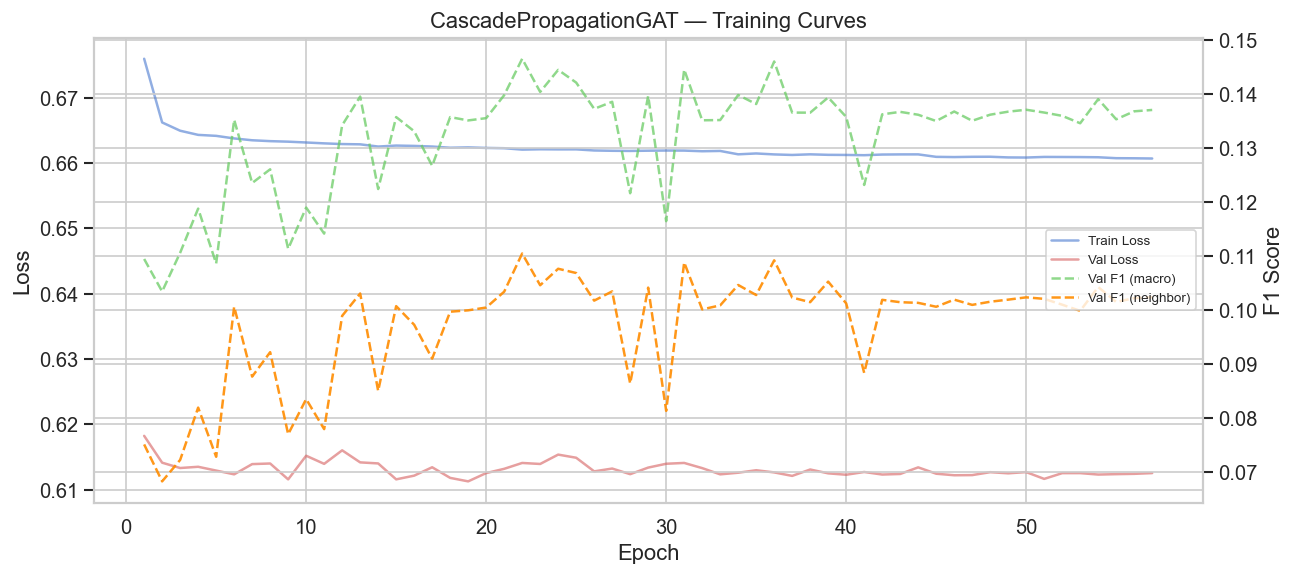

Model saved to ../models/gnn


In [12]:
# ── Save ──────────────────────────────────────────────────────────────
torch.save(model.state_dict(), MODEL_DIR / 'cascade_propagation_gat.pt')
with open(MODEL_DIR / 'gat_results.pkl', 'wb') as f:
    pickle.dump({
        'overall': overall,
        'per_label': per_label_df.to_dict(),
        'history': history,
        'thresholds': thresholds.tolist(),
        'target_names': TARGET_NAMES,
        'fips_to_idx': fips_to_idx,
    }, f)

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
l1, = ax.plot(epochs_range, history['train_loss'], 'b-', alpha=0.6, label='Train Loss')
l2, = ax.plot(epochs_range, history['val_loss'], 'r-', alpha=0.6, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax2 = ax.twinx()
l3, = ax2.plot(epochs_range, history['val_f1'], 'g--', alpha=0.75, label='Val F1 (macro)')
if 'val_f1_nonsrc' in history and len(history['val_f1_nonsrc']) == len(epochs_range):
    l4, = ax2.plot(epochs_range, history['val_f1_nonsrc'], color='darkorange', linestyle='--', alpha=0.9, label='Val F1 (neighbor)')
    ax2.legend(handles=[l1, l2, l3, l4], loc='center right', fontsize=8)
else:
    ax2.legend(handles=[l1, l2, l3], loc='center right', fontsize=8)
ax2.set_ylabel('F1 Score')
ax.set_title('CascadePropagationGAT — Training Curves')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'gat_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Model saved to {MODEL_DIR}")


---
## 5. Cascade Propagation Visualization

Animate how the GNN propagates disaster risk from source counties outward:
1. **Seed**: Primary event lights up source county
2. **GAT Layer 1**: Risk spreads to immediate neighbors
3. **GAT Layer 2**: Neighbor representations refine before classification
4. **Prediction**: Final cascade probability map

In [13]:
# ── Load county shapefile ─────────────────────────────────────────────
SHAPEFILE_CACHE = CACHE_DIR / 'us_counties.gpkg'
if SHAPEFILE_CACHE.exists():
    print("Loading cached county shapefile ...")
    counties_gdf = gpd.read_file(SHAPEFILE_CACHE)
else:
    print("Downloading county shapefile ...")
    tiger_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip"
    counties_gdf = gpd.read_file(tiger_url)
    counties_gdf.to_file(SHAPEFILE_CACHE, driver='GPKG')

counties_gdf['FIPS'] = counties_gdf['STATEFP'] + counties_gdf['COUNTYFP']
EXCLUDE_STATES = {'02', '15', '60', '66', '69', '72', '78'}
counties_conus = counties_gdf[~counties_gdf['STATEFP'].isin(EXCLUDE_STATES)].copy()
print(f"CONUS counties: {len(counties_conus)}")

Loading cached county shapefile ...
CONUS counties: 3108


In [14]:
# ── Pick a dramatic test episode to visualize ─────────────────────────
# Find episode with most counties affected by cascades
best_ep_data = None
best_score = 0
for d in test_data:
    n_cascade_counties = (d.y.sum(dim=1) > 0).sum().item()
    n_counties = d.x.shape[0]
    score = n_cascade_counties * n_counties  # big + spread
    if score > best_score and n_counties >= 10:
        best_score = score
        best_ep_data = d

ep = best_ep_data
print(f"Episode {ep.episode_id}: {ep.x.shape[0]} counties in subgraph")
print(f"  Source counties: {int(ep.is_source.sum())}")
print(f"  Counties with cascades: {(ep.y.sum(dim=1) > 0).sum().item()}")

# Get layer-by-layer activations for this episode
model.eval()
with torch.no_grad():
    x = ep.x_scaled.to(DEVICE)
    ei = ep.edge_index.to(DEVICE)
    is_src = ep.is_source.to(DEVICE)
    
    # Forward pass capturing intermediates (no residuals)
    h_input = torch.cat([x, is_src.unsqueeze(-1)], dim=-1)
    h0 = model.input_proj(h_input)
    
    h1_raw, attn1 = model.gat1(h0, ei, return_attention_weights=True)
    h1 = model.norm1(F.elu(h1_raw))
    
    h2_raw, attn2 = model.gat2(h1, ei, return_attention_weights=True)
    h2 = model.norm2(F.elu(h2_raw))
    
    logits = model.classifier(h2)
    probs = torch.sigmoid(logits)

stages = {
    'input': ep.is_source.numpy(),  # just source flag
    'proj': np.linalg.norm(h0.cpu().numpy(), axis=1),
    'gat1': np.linalg.norm(h1.cpu().numpy(), axis=1),
    'gat2': np.linalg.norm(h2.cpu().numpy(), axis=1),
    'probs': probs.cpu().numpy().max(axis=1),
}

# Map subgraph nodes back to global FIPS
global_ids = ep.global_node_ids.numpy()
ep_lons = county_coords.iloc[global_ids]['lon'].values
ep_lats = county_coords.iloc[global_ids]['lat'].values
ep_names = county_coords.iloc[global_ids]['name'].values
ep_states = county_coords.iloc[global_ids]['state'].values
ep_fips = [idx_to_fips[g] for g in global_ids]

# Source county info
src_mask = ep.is_source.numpy() > 0.5
src_names = [f"{ep_names[i]}, {ep_states[i]}" for i in range(len(src_mask)) if src_mask[i]]
print(f"  Source counties: {', '.join(src_names[:5])}")

# Actual cascade results
y_true = ep.y.numpy()
cascade_counties = [(ep_names[i], ep_states[i]) for i in range(len(y_true)) if y_true[i].sum() > 0]
print(f"  Cascade counties: {', '.join(f'{n}, {s}' for n,s in cascade_counties[:5])}")

# Key insight: do non-source counties now have non-zero activation?
nonsrc_mask = ~src_mask
nonsrc_probs = probs.cpu().numpy().max(axis=1)[nonsrc_mask]
print(f"\n  Non-source counties: {nonsrc_mask.sum()}")
print(f"  Non-source max prob: {nonsrc_probs.max():.4f}")
print(f"  Non-source mean prob: {nonsrc_probs.mean():.4f}")
print(f"  Non-source nodes with prob > 0.3: {(nonsrc_probs > 0.3).sum()}")

Episode 193712: 15 counties in subgraph
  Source counties: 1
  Counties with cascades: 10
  Source counties: SAN JUAN, UTAH
  Cascade counties: APACHE, ARIZONA, COCONINO, ARIZONA, NAVAJO, ARIZONA, MESA, COLORADO, SAN JUAN, NEW MEXICO

  Non-source counties: 14
  Non-source max prob: 0.4911
  Non-source mean prob: 0.4910
  Non-source nodes with prob > 0.3: 14


In [15]:
# ── Animated propagation for this episode ─────────────────────────────
STAGE_KEYS = ['input', 'proj', 'gat1', 'gat2', 'probs']
STAGE_LABELS = [
    'Primary Event \u2014 Source County',
    'Input Projection',
    'GAT Layer 1 \u2014 Neighbor Propagation',
    'GAT Layer 2 \u2014 Local refinement',
    'Predicted Cascade Probability',
]

BACKGROUND = '#0a0e27'
NODE_CMAP = LinearSegmentedColormap.from_list(
    'disaster', ['#0a0e27', '#1b3a6b', '#2980b9', '#f39c12', '#e74c3c', '#ff1744'])
EDGE_CMAP = LinearSegmentedColormap.from_list(
    'attention', ['#0a0e2700', '#2980b944', '#f39c1288', '#e74c3ccc', '#ff1744ff'])

# Center view on this episode's counties
lon_center = np.mean(ep_lons)
lat_center = np.mean(ep_lats)
lon_range = max(np.ptp(ep_lons), 3) * 1.5
lat_range = max(np.ptp(ep_lats), 2) * 1.5

# Build edge segments for this subgraph
sub_ei = ep.edge_index.numpy()
edge_segs = []
edge_pairs = []
for e in range(sub_ei.shape[1]):
    s, d = sub_ei[0, e], sub_ei[1, e]
    if s != d:
        edge_segs.append([(ep_lons[s], ep_lats[s]), (ep_lons[d], ep_lats[d])])
        edge_pairs.append((s, d))

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BACKGROUND)
fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

# County boundaries as backdrop
counties_conus.boundary.plot(ax=ax, linewidth=0.15, color='#ffffff18')
ax.set_xlim(lon_center - lon_range/2, lon_center + lon_range/2)
ax.set_ylim(lat_center - lat_range/2, lat_center + lat_range/2)
ax.set_facecolor(BACKGROUND)
ax.set_axis_off()

title_text = ax.text(
    0.5, 0.97, '', transform=ax.transAxes, fontsize=15,
    color='white', fontweight='bold', ha='center', va='top',
    fontfamily='monospace',
    path_effects=[pe.withStroke(linewidth=3, foreground=BACKGROUND)])
sub_text = ax.text(
    0.5, 0.93, '', transform=ax.transAxes, fontsize=11,
    color='#8899bb', ha='center', va='top', fontfamily='monospace')

scatter = ax.scatter([], [], s=[], c=[], cmap=NODE_CMAP, zorder=5,
                     edgecolors='none', vmin=0, vmax=1)
lc = LineCollection([], linewidths=0.5, colors='#1a1f4e', zorder=2)
ax.add_collection(lc)

# Attention weights for GAT layers
attn1_ei = attn1[0].cpu().numpy()
attn1_w = attn1[1].cpu().numpy()
if attn1_w.ndim > 1: attn1_w = attn1_w.mean(axis=1)
attn2_ei = attn2[0].cpu().numpy()
attn2_w = attn2[1].cpu().numpy()
if attn2_w.ndim > 1: attn2_w = attn2_w.mean(axis=1)


def animate(frame_idx):
    stage = STAGE_KEYS[frame_idx]
    intensity = stages[stage]
    
    # Normalize to [0, 1]
    if stage == 'input':
        norm_intensity = intensity  # already 0/1
    elif stage == 'probs':
        norm_intensity = intensity  # already [0, 1]
    else:
        lo, hi = np.percentile(intensity, [5, 95])
        norm_intensity = np.clip((intensity - lo) / (hi - lo + 1e-8), 0, 1)
    
    sizes = 30 + norm_intensity * 200
    offsets = np.column_stack([ep_lons, ep_lats])
    scatter.set_offsets(offsets)
    scatter.set_array(norm_intensity)
    scatter.set_sizes(sizes)
    scatter.set_clim(0, 1)
    
    # Edge glow during GAT layers
    if stage in ('gat1', 'gat2'):
        a_ei = attn1_ei if stage == 'gat1' else attn2_ei
        a_w = attn1_w if stage == 'gat1' else attn2_w
        lookup = {}
        for e_i in range(a_ei.shape[1]):
            s, d = int(a_ei[0, e_i]), int(a_ei[1, e_i])
            if s != d:
                lookup[(s, d)] = float(a_w[e_i])
        
        ec, ew = [], []
        for (s, d) in edge_pairs:
            w = lookup.get((s, d), 0.0)
            w_n = min(w * 8, 1.0)
            ec.append(EDGE_CMAP(w_n))
            ew.append(0.3 + w_n * 3)
        lc.set_segments(edge_segs)
        lc.set_colors(ec)
        lc.set_linewidths(ew)
    else:
        lc.set_segments(edge_segs)
        lc.set_colors(['#1a1f4e'] * len(edge_segs))
        lc.set_linewidths([0.3] * len(edge_segs))
    
    title_text.set_text(f'Cascade Propagation \u2014 Episode {ep.episode_id}')
    sub_text.set_text(f'Stage {frame_idx+1}/{len(STAGE_KEYS)}: {STAGE_LABELS[frame_idx]}')
    return scatter, lc, title_text, sub_text


anim = FuncAnimation(fig, animate, frames=len(STAGE_KEYS),
                     interval=1500, blit=False, repeat=True)

gif_path = REPORTS_DIR / 'cascade_episode_propagation.gif'
anim.save(str(gif_path), writer=PillowWriter(fps=1), dpi=130,
          savefig_kwargs={'facecolor': BACKGROUND})
print(f"Saved: {gif_path}")

plt.close(fig)
from IPython.display import HTML
HTML(anim.to_jshtml())

Saved: ../results/gnn/cascade_episode_propagation.gif


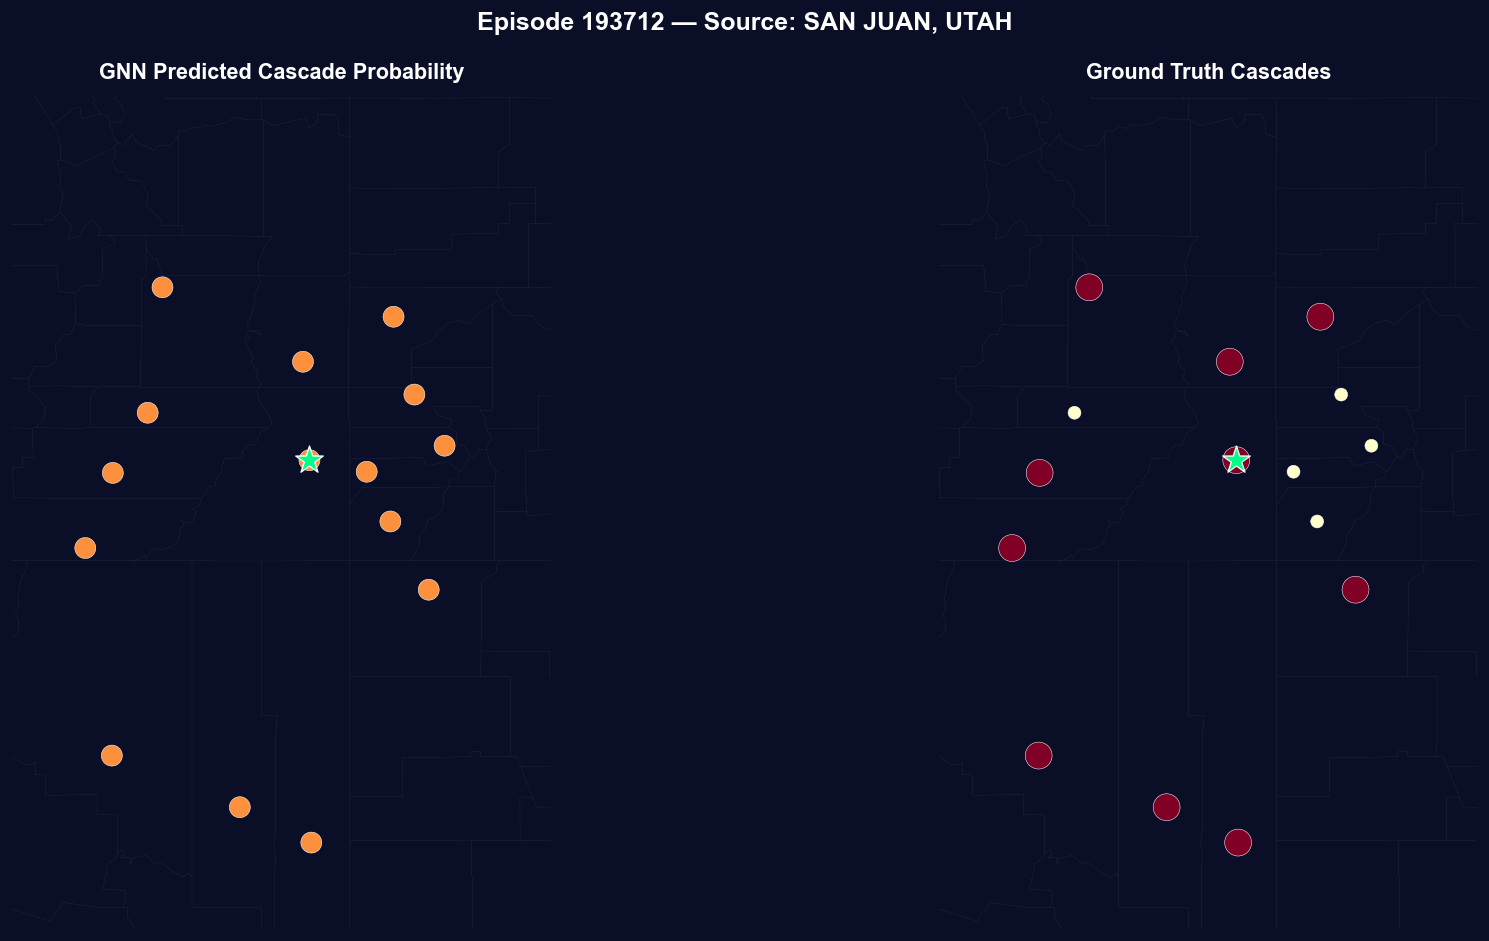

In [16]:
# ── Predicted vs Ground Truth map for the episode ─────────────────────
pred_probs = probs.cpu().numpy().max(axis=1)
true_cascade = ep.y.numpy().max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BACKGROUND)

for ax_i, (values, title, cmap_name) in enumerate([
    (pred_probs, 'GNN Predicted Cascade Probability', 'YlOrRd'),
    (true_cascade, 'Ground Truth Cascades', 'YlOrRd'),
]):
    ax = axes[ax_i]
    counties_conus.boundary.plot(ax=ax, linewidth=0.15, color='#ffffff18')
    ax.set_xlim(lon_center - lon_range/2, lon_center + lon_range/2)
    ax.set_ylim(lat_center - lat_range/2, lat_center + lat_range/2)
    ax.set_facecolor(BACKGROUND)
    ax.set_axis_off()
    
    # All subgraph nodes
    sc = ax.scatter(ep_lons, ep_lats, c=values, cmap=cmap_name,
                    s=60 + values * 200, vmin=0, vmax=1,
                    edgecolors='white', linewidth=0.3, zorder=5)
    
    # Mark source counties with stars
    src_lons = ep_lons[src_mask]
    src_lats = ep_lats[src_mask]
    ax.scatter(src_lons, src_lats, marker='*', s=300, c='#00ff88',
               edgecolors='white', linewidth=0.8, zorder=10)
    
    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=10)

plt.suptitle(f'Episode {ep.episode_id} \u2014 Source: {src_names[0]}',
             fontsize=15, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'cascade_pred_vs_truth.png'), dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

In [17]:
# ── Animate across multiple test episodes ─────────────────────────────
# Pick top 6 most interesting episodes (most cascade spread)
scored_episodes = []
for d in test_data:
    n_cascade = (d.y.sum(dim=1) > 0).sum().item()
    n_total = d.x.shape[0]
    if n_total >= 8 and n_cascade >= 2:
        scored_episodes.append((n_cascade, d))

scored_episodes.sort(key=lambda x: -x[0])
top_episodes = [d for _, d in scored_episodes[:6]]
print(f"Animating {len(top_episodes)} episodes")

# Pre-compute predictions
model.eval()
ep_viz_data = []
for d in top_episodes:
    with torch.no_grad():
        x_d = d.x_scaled.to(DEVICE)
        ei_d = d.edge_index.to(DEVICE)
        is_src_d = d.is_source.to(DEVICE)
        logits_d = model(x_d, ei_d, is_src_d)
        probs_d = torch.sigmoid(logits_d).cpu().numpy().max(axis=1)
    
    gids = d.global_node_ids.numpy()
    ep_viz_data.append({
        'ep_id': d.episode_id,
        'lons': county_coords.iloc[gids]['lon'].values,
        'lats': county_coords.iloc[gids]['lat'].values,
        'probs': probs_d,
        'true': d.y.numpy().max(axis=1),
        'source': d.is_source.numpy(),
        'names': county_coords.iloc[gids]['name'].values,
        'states': county_coords.iloc[gids]['state'].values,
    })

fig, ax = plt.subplots(figsize=(14, 8), facecolor=BACKGROUND)
fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

title_t = ax.text(0.5, 0.97, '', transform=ax.transAxes, fontsize=14,
                  color='white', fontweight='bold', ha='center', va='top',
                  fontfamily='monospace',
                  path_effects=[pe.withStroke(linewidth=3, foreground=BACKGROUND)])
sub_t = ax.text(0.5, 0.93, '', transform=ax.transAxes, fontsize=11,
                color='#8899bb', ha='center', va='top', fontfamily='monospace')


def animate_multi(frame):
    ax.clear()
    counties_conus.boundary.plot(ax=ax, linewidth=0.1, color='#ffffff15')
    ax.set_facecolor(BACKGROUND)
    ax.set_axis_off()
    
    d = ep_viz_data[frame]
    
    # Auto-zoom
    cx, cy = d['lons'].mean(), d['lats'].mean()
    rx = max(np.ptp(d['lons']), 3) * 1.5
    ry = max(np.ptp(d['lats']), 2) * 1.5
    ax.set_xlim(cx - rx/2, cx + rx/2)
    ax.set_ylim(cy - ry/2, cy + ry/2)
    
    # Plot predicted probabilities
    ax.scatter(d['lons'], d['lats'], c=d['probs'], cmap='YlOrRd',
               s=60 + d['probs'] * 200, vmin=0, vmax=1,
               edgecolors='white', linewidth=0.3, zorder=5)
    
    # Source stars
    sm = d['source'] > 0.5
    ax.scatter(d['lons'][sm], d['lats'][sm], marker='*', s=300,
               c='#00ff88', edgecolors='white', linewidth=0.8, zorder=10)
    
    src_name = d['names'][sm][0] if sm.sum() > 0 else '?'
    src_state = d['states'][sm][0] if sm.sum() > 0 else ''
    n_spread = (d['true'] > 0).sum()
    
    ax.set_title(
        f'Episode {d["ep_id"]} \u2014 Source: {src_name}, {src_state}\n'
        f'{d["probs"].shape[0]} counties, {n_spread} with cascades',
        fontsize=13, fontweight='bold', color='white', pad=10)


anim_multi = FuncAnimation(fig, animate_multi, frames=len(ep_viz_data),
                           interval=2000, repeat=True)

multi_path = REPORTS_DIR / 'cascade_multi_episodes.gif'
anim_multi.save(str(multi_path), writer=PillowWriter(fps=0.7), dpi=130,
                savefig_kwargs={'facecolor': BACKGROUND})
print(f"Saved: {multi_path}")
plt.close(fig)
HTML(anim_multi.to_jshtml())

Animating 6 episodes


Saved: ../results/gnn/cascade_multi_episodes.gif


---
## 6. Summary

**What this model does differently from the tabular models (NB02-04):**
- Tabular models predict *what* cascade types a single event triggers
- This GNN predicts *where* cascades spread spatially across the county graph

**Fairness angle:**
- Counties with sparse reporting still get cascade predictions via neighbor signal
- The GAT attention weights show which county connections the model relies on

**Key outputs:**
- `cascade_episode_propagation.gif` \u2014 single episode step-by-step propagation
- `cascade_pred_vs_truth.png` \u2014 predicted vs actual cascade map
- `cascade_multi_episodes.gif` \u2014 multiple episodes animated

Saved glorious analysis map to: ../results/gnn/high_res_us_map_analysis.png


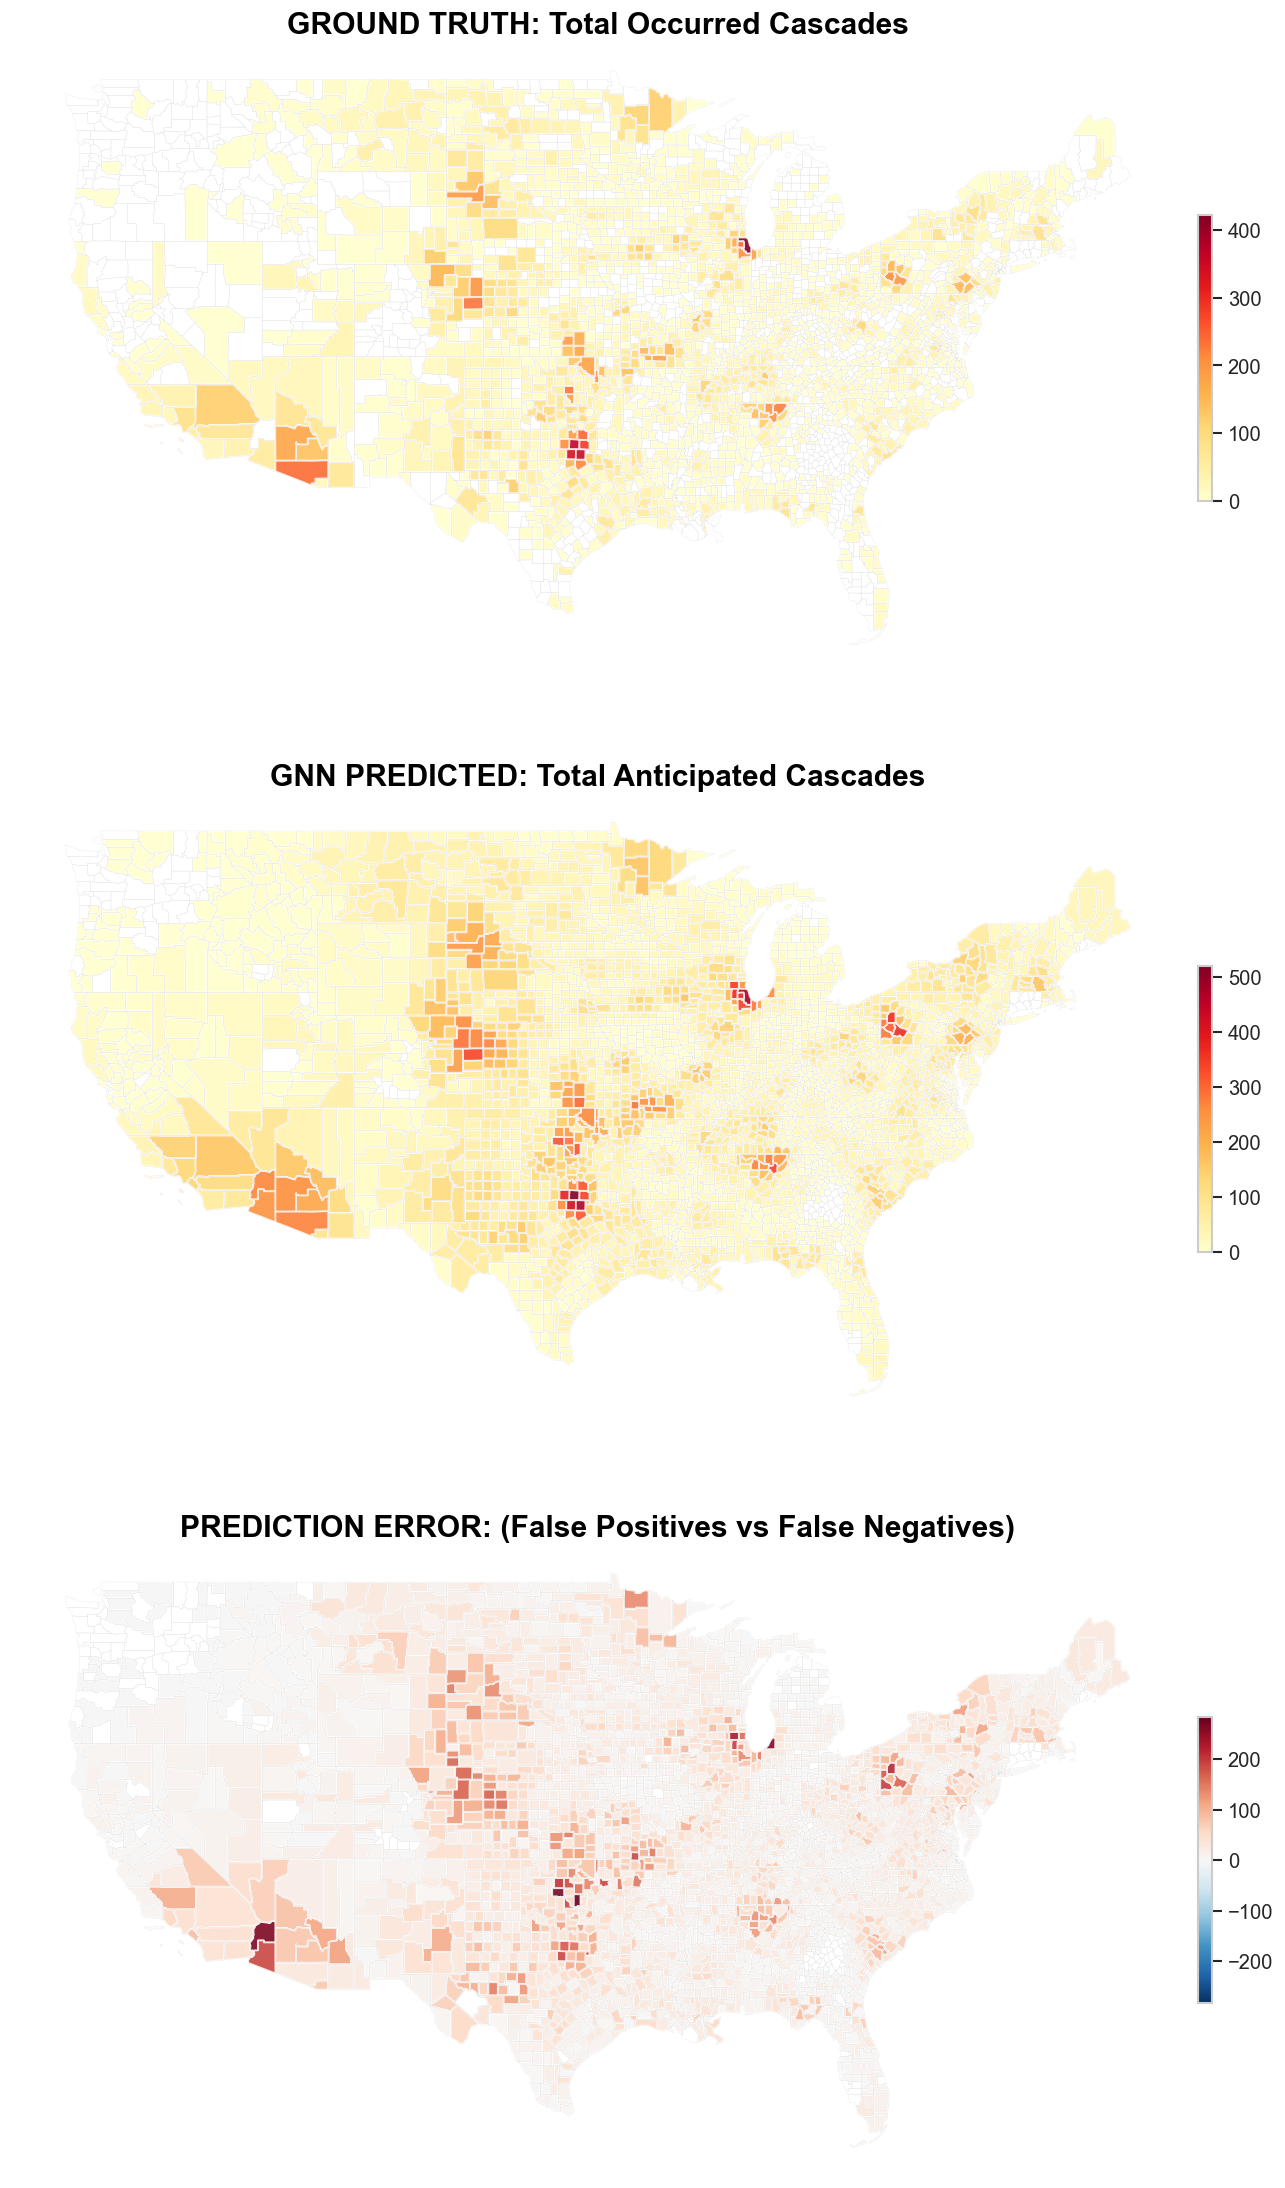

In [18]:
# ── 1. High-End Geographic Residuals Map ────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Accumulate probabilities and ground truth across all test episodes
total_pred = np.zeros(len(county_coords))
total_true = np.zeros(len(county_coords))

model.eval()
t_thresh = np.array(thresholds) if not hasattr(thresholds, "cpu") else thresholds.cpu().numpy()

for d in test_data:
    with torch.no_grad():
        logits_d = model(d.x_scaled.to(DEVICE), d.edge_index.to(DEVICE), d.is_source.to(DEVICE))
        probs_d = torch.sigmoid(logits_d).cpu().numpy()
    
    # Max over all cascade types per county
    preds_d = (probs_d >= t_thresh).astype(int).max(axis=1)
    true_d = d.y.numpy().max(axis=1)
    
    gids = d.global_node_ids.numpy()
    total_pred[gids] += preds_d
    total_true[gids] += true_d

temp_df = county_coords.copy().reset_index()
if "FIPS" not in temp_df.columns: temp_df = temp_df.rename(columns={"index": "FIPS"})
temp_df["pred_cascades"] = total_pred
temp_df["true_cascades"] = total_true

plot_df = counties_conus.merge(temp_df[["FIPS", "pred_cascades", "true_cascades"]], on="FIPS", how="left")
plot_df["pred_cascades"] = plot_df["pred_cascades"].fillna(0)
plot_df["true_cascades"] = plot_df["true_cascades"].fillna(0)
plot_df["residual Error"] = plot_df["pred_cascades"] - plot_df["true_cascades"]

# Map Plotting
bg = "#ffffff"  # White background
fig, axes = plt.subplots(3, 1, figsize=(15, 24), facecolor=bg)
fig.subplots_adjust(hspace=0.05)

max_err = max(abs(plot_df["residual Error"].min()), abs(plot_df["residual Error"].max()), 1)

panels = [
    ("true_cascades", "GROUND TRUTH: Total Occurred Cascades", "YlOrRd", 0, None),
    ("pred_cascades", "GNN PREDICTED: Total Anticipated Cascades", "YlOrRd", 0, None),
    ("residual Error", "PREDICTION ERROR: (False Positives vs False Negatives)", "RdBu_r", -max_err, max_err)
]

for ax, (col, title, cmap, vmin, vmax) in zip(axes, panels):
    ax.set_facecolor(bg)
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    # Plot base counties in light grey to blend with white background
    counties_conus.boundary.plot(ax=ax, linewidth=0.15, color="#dddddd")
    
    # Plot Heatmap with hotspots going extremely red
    active = plot_df[plot_df[col] != 0] if col == "residual Error" else plot_df[plot_df[col] > 0]
    if not active.empty:
        active.plot(column=col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.9, 
                    legend=True, legend_kwds={"shrink": 0.4, "pad": 0.01})
    
    # Aesthetic Title (Black text for white background)
    ax.set_title(title, fontsize=18, fontweight="bold", color="black", pad=5)

map_path = REPORTS_DIR / "high_res_us_map_analysis.png"
plt.savefig(str(map_path), dpi=200, bbox_inches="tight", facecolor=bg)
print(f"Saved glorious analysis map to: {map_path}")
plt.show()


Case: test split, trigger in ALLEGHENY Co., PENNSYLVANIA — Hail on 2024-04-14 21:00:00
Subgraph: 5 counties, 3 with observed cascades


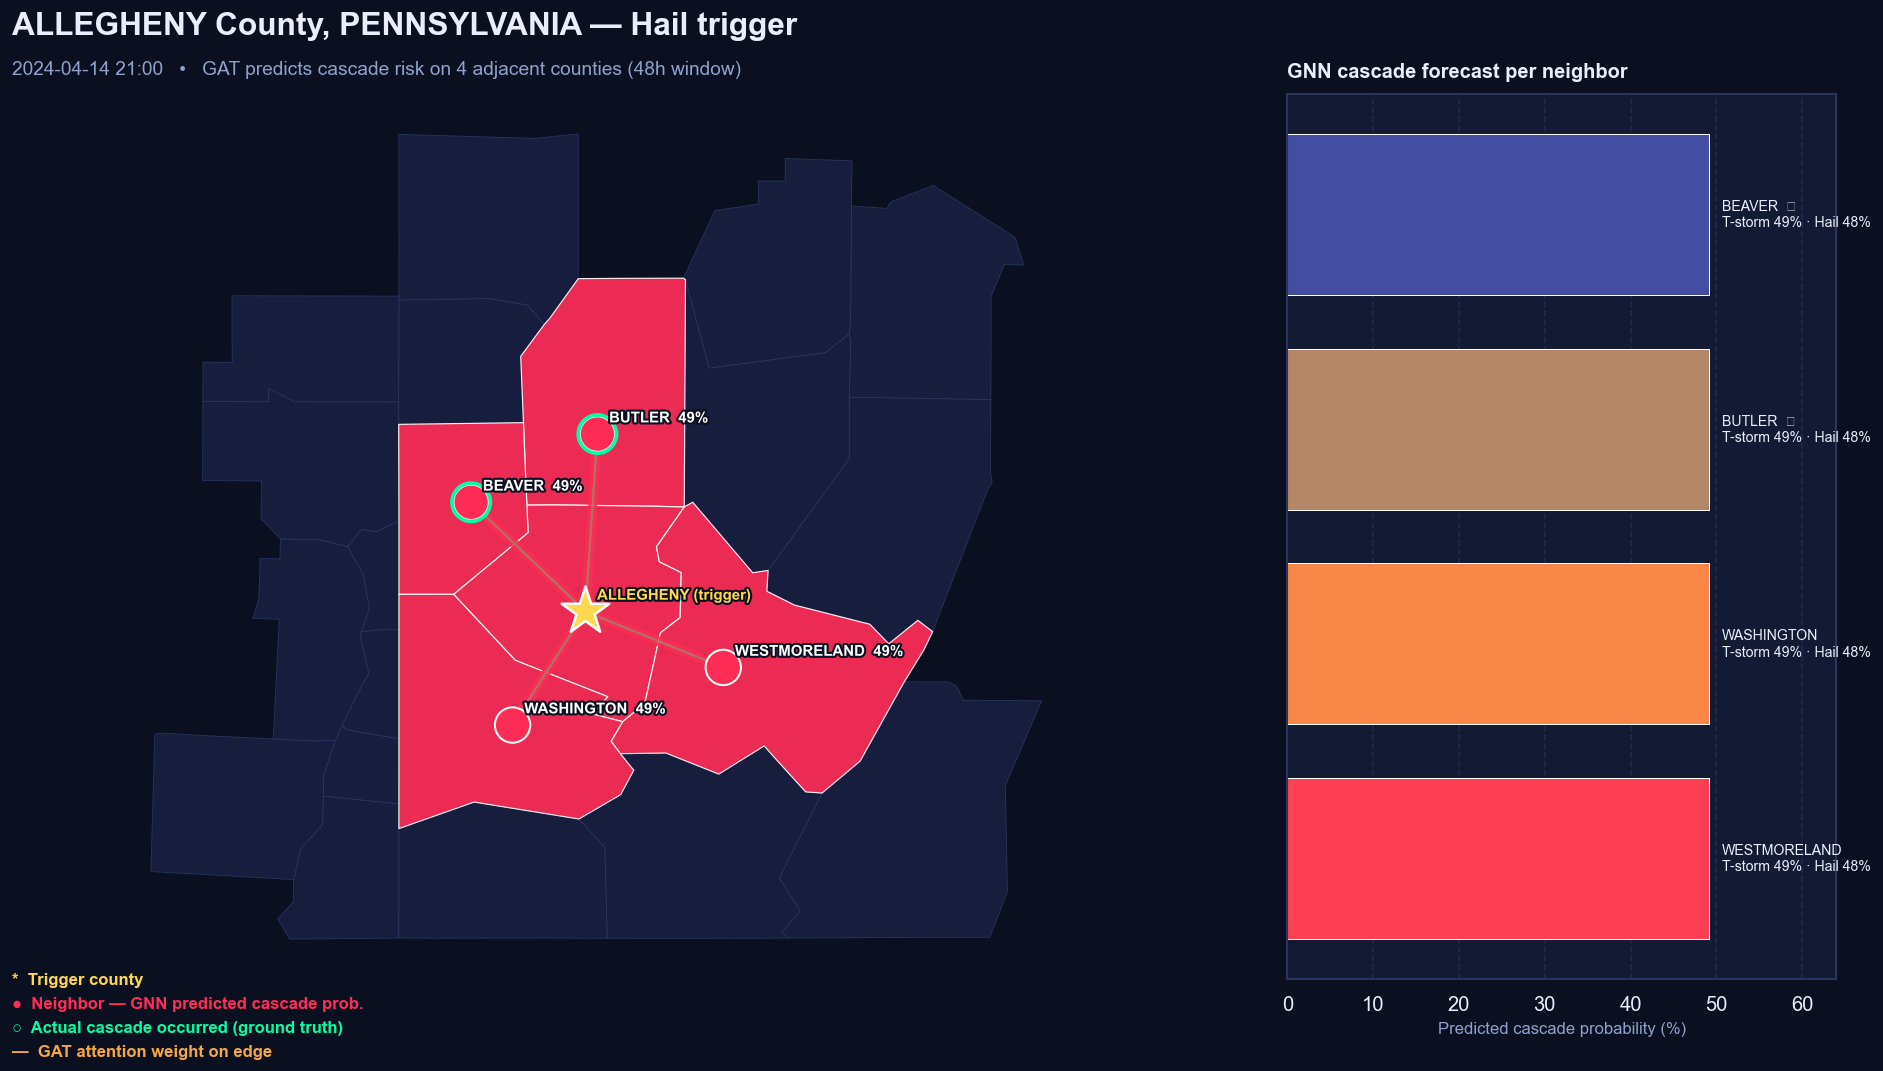

Saved presentation figure -> ../results/gnn/pittsburgh_cascade_propagation.png


In [19]:
# ── Pittsburgh case study — Allegheny County trigger ──────────────────
# Presentation-grade figure: pick a real trigger event in Allegheny County
# (FIPS 42003), show the 1-hop subgraph with GAT predictions on neighbors,
# attention-weighted edges, and the actual cascade outcome.

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import box as _shbox

ALLEGHENY_FIPS = "42003"

def _ep_src_fips(d):
    src_local = int((d.is_source > 0.5).nonzero(as_tuple=True)[0][0])
    return idx_to_fips[int(d.global_node_ids[src_local])]

def _ep_cascade_count(d):
    return int((d.y.sum(dim=1) > 0).sum().item())

candidates = []
for split_name, split in [("test", test_data), ("val", val_data), ("train", train_data)]:
    for d in split:
        if _ep_src_fips(d) == ALLEGHENY_FIPS:
            candidates.append((split_name, _ep_cascade_count(d), d))
    if candidates:
        break

if not candidates:
    fallback = {"42125", "42129", "42007", "42019", "42005", "42051", "42063"}
    for split_name, split in [("test", test_data), ("val", val_data), ("train", train_data)]:
        for d in split:
            if _ep_src_fips(d) in fallback:
                candidates.append((split_name, _ep_cascade_count(d), d))
        if candidates:
            break

candidates.sort(key=lambda x: -x[1])
use_split, use_cascades, pgh_ep = candidates[0]
src_local = int((pgh_ep.is_source > 0.5).nonzero(as_tuple=True)[0][0])
src_fips_ = idx_to_fips[int(pgh_ep.global_node_ids[src_local])]
src_row = events[(events["FIPS"] == src_fips_) &
                 (events["EVENT_ID"].astype(str) == str(pgh_ep.trigger_event_id))].iloc[0]
print(f"Case: {use_split} split, trigger in {src_row['CZ_NAME']} Co., {src_row['STATE']} "
      f"— {src_row['EVENT_TYPE']} on {src_row['BEGIN_DATETIME']}")
print(f"Subgraph: {pgh_ep.x.shape[0]} counties, {use_cascades} with observed cascades")

model.eval()
with torch.no_grad():
    x = pgh_ep.x_scaled.to(DEVICE)
    ei = pgh_ep.edge_index.to(DEVICE)
    is_src = pgh_ep.is_source.to(DEVICE)
    logits, (attn1, attn2) = model(x, ei, is_src, return_attention=True)
    probs_pgh = torch.sigmoid(logits).cpu().numpy()

gids = pgh_ep.global_node_ids.numpy()
lons = county_coords.iloc[gids]["lon"].values
lats = county_coords.iloc[gids]["lat"].values
names = county_coords.iloc[gids]["name"].values
states = county_coords.iloc[gids]["state"].values
y_true = pgh_ep.y.numpy()
src_mask = pgh_ep.is_source.numpy() > 0.5

max_prob = probs_pgh.max(axis=1)
true_any = y_true.max(axis=1).astype(bool)

BG = "#0b1020"
PANEL = "#131a33"
TEXT = "#eaeefb"
MUTED = "#8ea0cc"

fig = plt.figure(figsize=(16, 9), facecolor=BG)
gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1.0], wspace=0.10,
                      left=0.02, right=0.98, top=0.90, bottom=0.08)
ax_map = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])

try:
    _cj = counties_conus.to_crs(4326) if counties_conus.crs is not None else counties_conus
except Exception:
    _cj = counties_conus
pgh_box = _shbox(min(lons) - 0.4, min(lats) - 0.3, max(lons) + 0.4, max(lats) + 0.3)
frame = _cj[_cj.geometry.intersects(pgh_box)]

ax_map.set_facecolor(BG)
ax_map.set_axis_off()
frame.plot(ax=ax_map, facecolor="#161d3d", edgecolor="#2a345f", linewidth=0.5)

sub_fips = [idx_to_fips[int(g)] for g in gids]
frame_sub = _cj[_cj["FIPS"].isin(sub_fips)].copy()
frame_sub = frame_sub.merge(
    pd.DataFrame({"FIPS": sub_fips, "prob": max_prob,
                  "is_src": src_mask.astype(int), "truth": true_any.astype(int)}),
    on="FIPS", how="left",
)
prob_cmap = LinearSegmentedColormap.from_list(
    "risk", ["#1b2660", "#3a4aa8", "#f5a742", "#ff2d55"])
vmax_p = max(0.25, float(max_prob.max()))
frame_sub.plot(column="prob", cmap=prob_cmap, ax=ax_map,
               vmin=0, vmax=vmax_p,
               edgecolor="white", linewidth=0.7, alpha=0.92)

sub_ei = pgh_ep.edge_index.numpy()
a1_ei = attn1[0].cpu().numpy()
a1_w = attn1[1].cpu().numpy()
if a1_w.ndim > 1:
    a1_w = a1_w.mean(axis=1)
attn_lookup = {}
for e_i in range(a1_ei.shape[1]):
    s, d = int(a1_ei[0, e_i]), int(a1_ei[1, e_i])
    if s != d:
        attn_lookup[(s, d)] = max(attn_lookup.get((s, d), 0.0), float(a1_w[e_i]))

a_vals = [v for (s, d), v in attn_lookup.items() if s == src_local or d == src_local]
a_max = max(a_vals) if a_vals else 1.0
edge_cmap = LinearSegmentedColormap.from_list(
    "attn", ["#3a4aa855", "#f5a742cc", "#ff2d55ff"])
segs, widths, colors = [], [], []
for e_i in range(sub_ei.shape[1]):
    s, d = int(sub_ei[0, e_i]), int(sub_ei[1, e_i])
    if s == d or (s != src_local and d != src_local):
        continue
    w = attn_lookup.get((s, d), 0.0)
    w_n = min(w / (a_max + 1e-8), 1.0)
    segs.append([(lons[s], lats[s]), (lons[d], lats[d])])
    widths.append(1.2 + w_n * 4.5)
    colors.append(edge_cmap(0.25 + 0.75 * w_n))
ax_map.add_collection(LineCollection(segs, linewidths=widths, colors=colors,
                                     zorder=3, capstyle="round", alpha=0.85))

neigh_mask = ~src_mask
ax_map.scatter(lons[neigh_mask], lats[neigh_mask],
               c=max_prob[neigh_mask], cmap=prob_cmap,
               vmin=0, vmax=vmax_p,
               s=180 + 550 * max_prob[neigh_mask],
               edgecolor="white", linewidth=1.2, zorder=6)

truth_nbr = neigh_mask & true_any
if truth_nbr.any():
    ax_map.scatter(lons[truth_nbr], lats[truth_nbr],
                   s=260 + 550 * max_prob[truth_nbr],
                   facecolors="none", edgecolors="#00ffa3",
                   linewidths=2.2, zorder=7)

ax_map.scatter(lons[src_mask], lats[src_mask], marker="*", s=900,
               c="#ffd84d", edgecolor="white", linewidth=1.5, zorder=10)

for i in range(len(names)):
    if i == src_local:
        lbl = f"{names[i]} (trigger)"
        col = "#ffd84d"
    else:
        lbl = f"{names[i]}  {max_prob[i]*100:.0f}%"
        col = "#ffffff" if max_prob[i] > 0.15 else MUTED
    ax_map.annotate(
        lbl, (lons[i], lats[i]), xytext=(7, 7), textcoords="offset points",
        fontsize=9, color=col, fontweight="bold",
        path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)], zorder=11,
    )

title = f"{src_row['CZ_NAME']} County, {src_row['STATE']} — {src_row['EVENT_TYPE']} trigger"
subtitle = (f"{pd.to_datetime(src_row['BEGIN_DATETIME']).strftime('%Y-%m-%d %H:%M')}   •   "
            f"GAT predicts cascade risk on {int(neigh_mask.sum())} adjacent counties "
            f"(48h window)")
fig.text(0.03, 0.955, title, fontsize=19, color=TEXT, fontweight="bold")
fig.text(0.03, 0.918, subtitle, fontsize=11.5, color=MUTED)

legend_items = [
    ("*  Trigger county", "#ffd84d"),
    ("●  Neighbor — GNN predicted cascade prob.", "#ff2d55"),
    ("○  Actual cascade occurred (ground truth)", "#00ffa3"),
    ("—  GAT attention weight on edge", "#f5a742"),
]
for k, (lbl, c) in enumerate(legend_items):
    fig.text(0.03, 0.075 - k * 0.022, lbl, fontsize=10, color=c, fontweight="bold")

ax_bar.set_facecolor(PANEL)
for s in ax_bar.spines.values():
    s.set_color("#2a345f")
ax_bar.tick_params(colors=TEXT)
ax_bar.set_title("GNN cascade forecast per neighbor",
                 color=TEXT, fontsize=12, fontweight="bold", pad=10, loc="left")

nbr_idx = np.where(neigh_mask)[0]
nbr_idx = nbr_idx[np.argsort(-max_prob[nbr_idx])][:10]
bar_colors = prob_cmap(np.linspace(0.35, 0.95, len(nbr_idx)))
y_pos = np.arange(len(nbr_idx))
ax_bar.barh(y_pos, max_prob[nbr_idx] * 100, color=bar_colors,
            edgecolor="white", linewidth=0.6, height=0.75)

for k, i in enumerate(nbr_idx):
    top2 = np.argsort(-probs_pgh[i])[:2]
    lbl_str = " · ".join(
        f"{TARGET_NAMES[j].replace(' Wind','').replace('Thunderstorm','T-storm')}"
        f" {probs_pgh[i,j]*100:.0f}%" for j in top2
    )
    truth_mark = "  ✓" if true_any[i] else ""
    ax_bar.text(max_prob[i] * 100 + 1.5, k,
                f"{names[i]}{truth_mark}\n{lbl_str}",
                va="center", ha="left", fontsize=8.5, color=TEXT)

ax_bar.set_yticks([])
ax_bar.set_xlim(0, max(10, max_prob[nbr_idx].max() * 130))
ax_bar.set_xlabel("Predicted cascade probability (%)", color=MUTED, fontsize=10)
ax_bar.invert_yaxis()
ax_bar.grid(axis="x", color="#2a345f", alpha=0.6, linestyle="--")

out_path = REPORTS_DIR / "pittsburgh_cascade_propagation.png"
plt.savefig(out_path, dpi=220, facecolor=BG, bbox_inches="tight")
plt.show()
print(f"Saved presentation figure -> {out_path}")


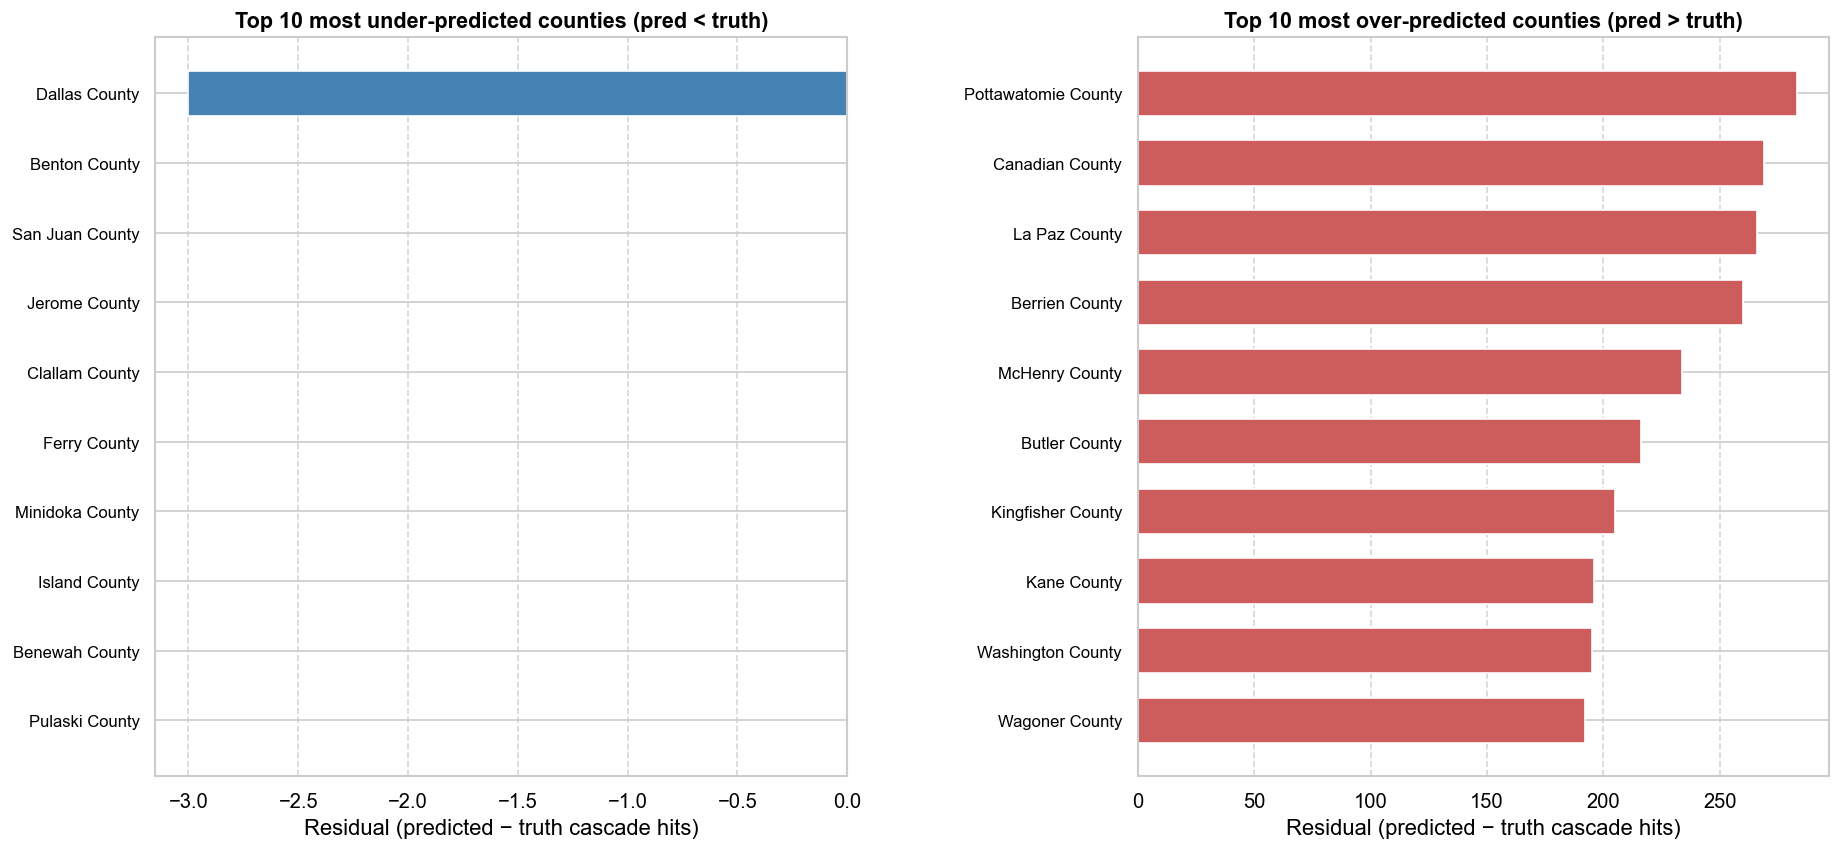

In [20]:
# ── 3. Spotlight on Model Blindspots (Hotspot Bars) ───────────────

df_stats = plot_df.dropna(subset=["residual Error"]).copy()
# Census county shapefiles use NAME + STUSPS or NAMELSAD — not STATE_NAME
if "NAMELSAD" in df_stats.columns:
    df_stats["County_State"] = df_stats["NAMELSAD"].astype(str)
elif "STUSPS" in df_stats.columns:
    df_stats["County_State"] = df_stats["NAME"].astype(str) + ", " + df_stats["STUSPS"].astype(str)
else:
    df_stats["County_State"] = df_stats["NAME"].astype(str)

top_fn = df_stats.sort_values("residual Error").head(10)
top_fp = df_stats.sort_values("residual Error", ascending=False).head(10)

_bg = "#ffffff"
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=_bg)
fig.subplots_adjust(wspace=0.42)

# matplotlib barh avoids seaborn palette/hue API issues on recent versions
_y = np.arange(len(top_fn))
axes[0].barh(_y, top_fn["residual Error"].values, color="steelblue", height=0.65)
axes[0].set_yticks(_y)
axes[0].set_yticklabels(list(top_fn["County_State"].values), fontsize=10)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 most under-predicted counties (pred < truth)", color="black", weight="bold", size=13)
axes[0].set_xlabel("Residual (predicted − truth cascade hits)", color="black")
axes[0].grid(axis="x", color="#cccccc", linestyle="--", alpha=0.8)
axes[0].set_facecolor(_bg)

_y2 = np.arange(len(top_fp))
axes[1].barh(_y2, top_fp["residual Error"].values, color="indianred", height=0.65)
axes[1].set_yticks(_y2)
axes[1].set_yticklabels(list(top_fp["County_State"].values), fontsize=10)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 most over-predicted counties (pred > truth)", color="black", weight="bold", size=13)
axes[1].set_xlabel("Residual (predicted − truth cascade hits)", color="black")
axes[1].grid(axis="x", color="#cccccc", linestyle="--", alpha=0.8)
axes[1].set_facecolor(_bg)

for ax in axes:
    ax.tick_params(colors="black")

plt.savefig(str(REPORTS_DIR / "cascade_hotspots_bar.png"), dpi=150, bbox_inches="tight", facecolor=_bg)
plt.show()
